# Aprendizado Não Supervisionado

In [31]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

datadir = "https://raw.githubusercontent.com/ahirtonlopes/Unsupervised_Learning/main/"

df_penguins = pd.read_csv(datadir + "penguins.csv")
df_penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


<Axes: xlabel='bill_depth_mm', ylabel='flipper_length_mm'>

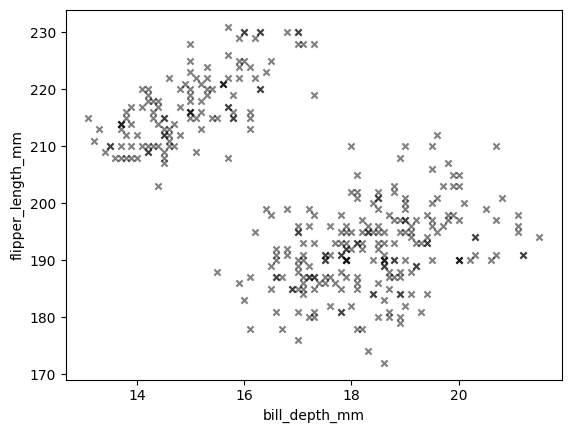

In [32]:
X_train = df_penguins[["bill_depth_mm", "flipper_length_mm"]]
X_train.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",c="black",marker="x",alpha=.5)

<Axes: xlabel='bill_depth_mm', ylabel='flipper_length_mm'>

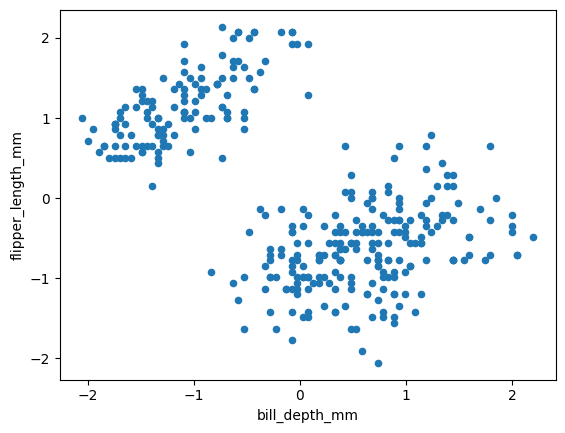

In [33]:
X_train_scaled = (X_train - X_train.mean()) / X_train.std()
X_train_scaled.plot.scatter(x="bill_depth_mm", y="flipper_length_mm")

## Implementando K-means do zero

,bill_depth_mm,flipper_length_mm
r,0.885576,-0.918466
b,-0.937399,1.641677
g,1.594512,-0.491775


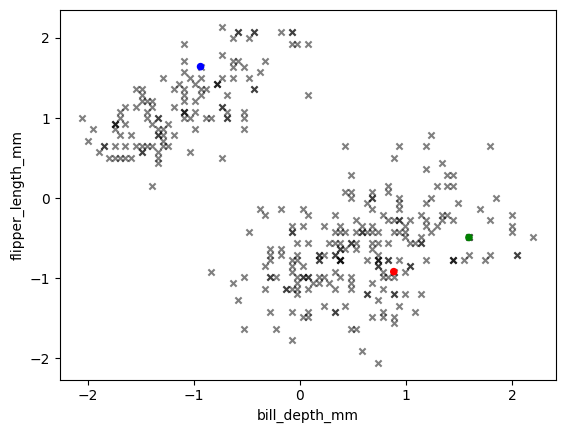

In [34]:
centroids = X_train_scaled.sample(3)

centroids.index = ["r","b","g"]

ax = X_train_scaled.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",c="black",marker="x",alpha=.5)

centroids.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",c=centroids.index,ax=ax)

centroids

In [35]:
def get_nearest_centroid(obs):
    dists = np.sqrt(((centroids - obs)**2).sum(axis=1))
    return dists.idxmin()

get_nearest_centroid(X_train_scaled.loc[0])

'r'

<Axes: xlabel='bill_depth_mm', ylabel='flipper_length_mm'>

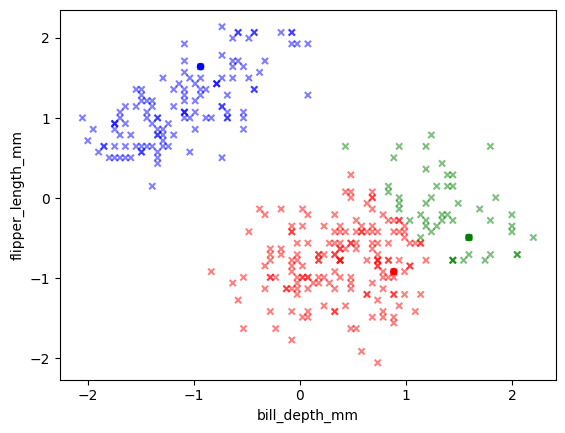

In [36]:
clusters = X_train_scaled.apply(get_nearest_centroid, axis=1)

ax = X_train_scaled.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",c=clusters,marker="x",alpha=.5)

centroids.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",c=centroids.index,ax=ax)


,bill_depth_mm,flipper_length_mm
b,-1.098371,1.157170
g,1.399048,-0.146156
r,0.385487,-0.798959


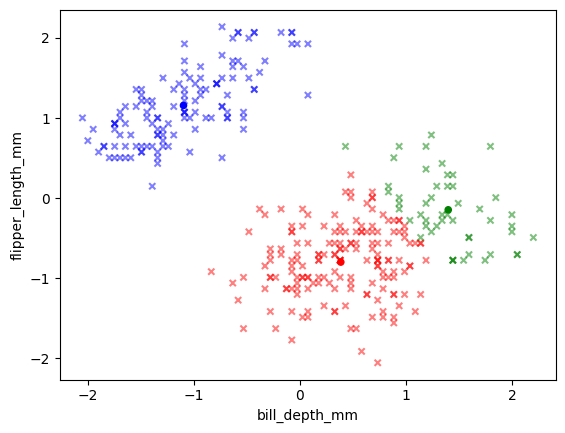

In [37]:
centroids = X_train_scaled.groupby(clusters).mean()

ax = X_train_scaled.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",c=clusters,marker="x",alpha=.5)

centroids.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",c=centroids.index,ax=ax)

centroids

<Axes: xlabel='bill_depth_mm', ylabel='flipper_length_mm'>

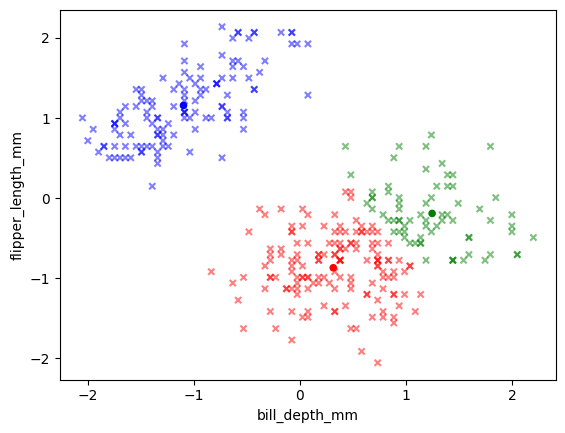

In [38]:
clusters = X_train_scaled.apply(get_nearest_centroid, axis=1)

centroids = X_train_scaled.groupby(clusters).mean()

ax = X_train_scaled.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",c=clusters,marker="x",alpha=.5)

centroids.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",c=centroids.index,ax=ax)

## K-means em scikit-learn

In [43]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Remove linhas com NaN
X_train_clean = X_train.dropna()

model = KMeans(n_clusters=3, n_init=10)

pipeline = make_pipeline(StandardScaler(), model)
pipeline.fit(X_train_clean)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. Th

In [ ]:
centroids = model.cluster_centers_

clusters = model.labels_

clusters

<Axes: xlabel='bill_depth_mm', ylabel='flipper_length_mm'>

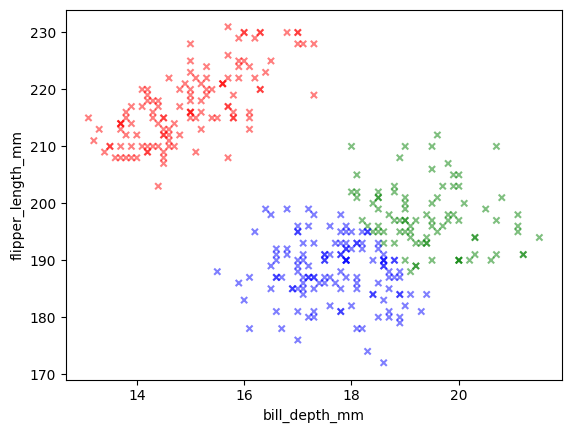

In [48]:
clusters = pd.Series(model.labels_, index=X_train_clean.index).map({
    0: "r",
    1: "b",
    2: "g"
})
X_train_clean.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",c=clusters,marker="x",alpha=.5)

In [49]:
pipeline.predict([[15,210]])

/workspaces/FIAP_POS_ML_MOD3/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0], dtype=int32)